In [ ]:
import Pkg; Pkg.activate(".")
using StatsBase, Distributions, Plots, NPZ

In [2]:
include("equalize.jl")

myecdf (generic function with 1 method)

# Test theoretical distribution

In [3]:
mypdf = Normal(0, 1)
Ftheo(x) = cdf(mypdf, x)
invFtheo(p) = quantile(mypdf, p)
Δ = 0.05; N = 10

u, α  = dichotomy(Ftheo, invFtheo; tol = 1e-8)

LoadError: UndefVarError: `Normal` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

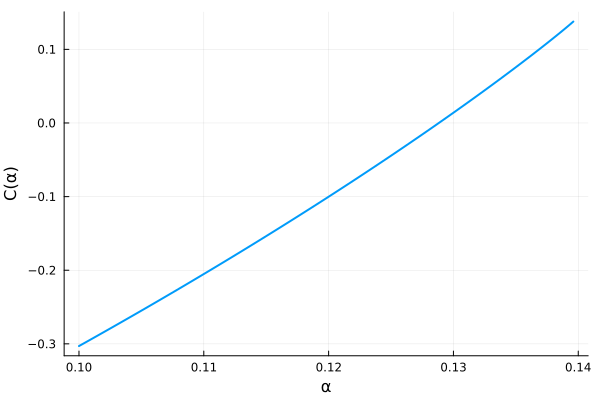

In [58]:
α_pl = LinRange(1/N, 0.2, 256)
cost = map(α -> comp_u(α, Ftheo, invFtheo)[1], α_pl)
if any(x -> x === nothing, cost)
	nc = findfirst(x -> isnothing(x), cost) - 1
else
	nc = length(cost)
end
fig1 = plot(α_pl[1:nc], cost[1:nc], label="", w=2)
xlabel!("α")
ylabel!("C(α)")

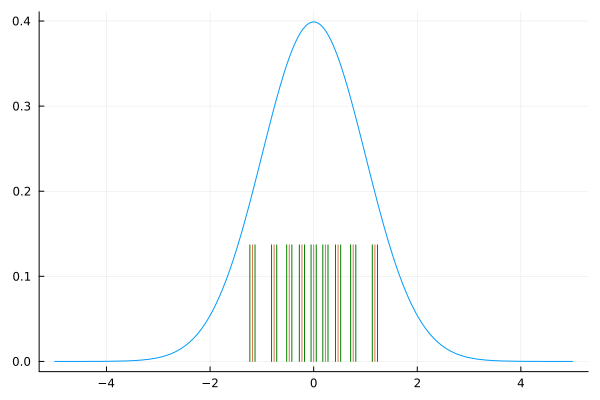

In [12]:
# plot figure
histo = plot(x -> pdf(mypdf, x), label = "")
histo_max = ylims(histo)[2]/3
plot!(u, histo_max*ones(size(u)), seriestype=:stem, label = "")
plot!(u .+ Δ, histo_max*ones(size(u)), seriestype=:stem, label = "", color = :green)
plot!(u .- Δ, histo_max*ones(size(u)), seriestype=:stem, label = "", color = :green)

In [50]:
num_events(u, Ftheo, Δ)

10-element Vector{Float64}:
 0.12883010245859616
 0.12883010245859622
 0.12883010245859627
 0.12883010245859627
 0.12883010245859627
 0.12883010245859622
 0.12883010245859627
 0.12883010245859627
 0.12883010245859627
 0.12883010369736136

# Test visibilities

In [61]:
x = npzread("data/vis_distances_1chan_1h_midaa4.npy");

In [79]:
Δ = 1; N = 12
F = myecdf(x)
invF(p) = quantile!(F.sorted_values, p; sorted=true)

@time u, α  = dichotomy(F, invF;tol = 1e-12);

  0.906715 seconds (16.40 k allocations: 565.031 KiB, 0.94% compilation time: 100% of which was recompilation)


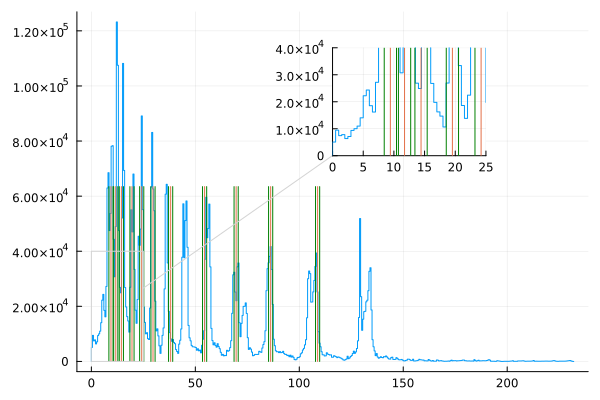

In [60]:
histo = histogram(x, nbins = 1000, label = "")
histo_max = ylims(histo)[2]/2
plot!(u, histo_max*ones(size(u)), seriestype=:stem, label = "")
plot!(u .+ Δ, histo_max*ones(size(u)), seriestype=:stem, label = "", color = :green)
plot!(u .- Δ, histo_max*ones(size(u)), seriestype=:stem, label = "", color = :green)
lens!([0, 25], [0, 4e4], inset=(1, bbox(0.5, 0.1, 0.3, 0.3)))

In [81]:
num_events(u, F, Δ)*length(x)

12-element Vector{Float64}:
 574421.0
 574421.0
 574420.9999999999
 574420.9999999999
 574420.9999999999
 574419.9999999999
 574420.0000000001
 574419.9999999999
 574419.9999999999
 574419.9999999999
 574419.9999999999
 574383.0000000002